# MOD510: Project 4

**Deadline: 01. December 2025 (23:59)**


**Group members**

* Simen Sæverud Gåsland

* Nataliia Aksamentova

# Abstract 
This project investigates two stochastic modelling problems using Monte Carlo simulations and random walk methods. In the first exercise, Monte Carlo simulations are used to model concentration dynamics in single and interconnected mixing tanks under uncertain inflow rates, outflow rates, volumes, and initial conditions. The Monte Carlo mean closely matches the deterministic ODE solutions, with mean absolute errors below $0.02$ g/L. Across all three tanks, the stochastic simulations remain consistent, with $95\%$ confidence interval widths remaining small $(\approx 0.05 - 0.08 \text{ g/L})$. All concentrations converge towards zero due to zero concentration inflow. A performance comparison shows that Monte Carlo is significantly slower than deterministic ODE solvers. 

In the second exercise, contaminant spreading in an underground aquifer is modeled using two-dimensional random walks. A spatial concentration map is generated from thousands of particle trajectories, and travel times to a target distance of $10$ km are analyzed. For the unbiased walk, the arrival time distribution is highly skewed with a heavy tail, reflecting large variability and extremely long travel times. A worst-case estimate gives a minimum of $1000$ years, and the simulations frequently exceed this scale. Introducing a southward bias drastically reduces travel times and produced an approximately normal arrival time distribution. The most likely arrival time in the unbiased case is more than $200$ times larger than in the biased case. 

# Introduction
Stochastic modelling plays a key role in engineering applications where system parameters or physical processes exhibit randomness. This project focuses on two such cases: uncertainty in mixing tank systems and the transport of contaminants in underground aquifers. 

In the first part of the project, uncertainty in the inflow rate, outflow rate, tank volume and initial concentration is added to the mixing tank model. Monte Carlo simulations are used to show how this uncertainty affects concentration over time and to compute confidence intervals. The results are compared with the deterministic ODE solution to evaluate how accurate the Monte Carlo approach is and how much more computational effort it requires. 

In the second part of the project, a two-dimensional random walk model is used to simulate how contaminants spread in an aquifer. The random walk helps estimate how the contaminant spreads out and allows us to estimate where it goes and how long it takes to reach a certain distance. A directional bias is then added to the random walk to represent a preferred movement direction. 

# Exercise 1: Stochastic modeling of mixing tanks


Exercise $1$ uses Monte Carlo simulations to study how uncertainty affects concentration in mixing tanks. We start with a single tank and then extend the model to three connected tanks. The results are compared with deterministic ODE solutions to see how well Monte Carlo approach performs and how much uncertainty it introduces. 

## Part 1: Single Mixing Tank with Parameter Uncertainty 

### Task 1 - Derivation of the concentration in a single mixing tank

We concider a well-mixed tank with constant volume $V$, inflow rate $Q_{in}$, outflow rate $Q_{out}$ and constant inflow concentration $C_{in}$.

To determine the solute concentration in the tank, $C(t)$, the following governing differential equation must be solved: 


$$\frac{dC}{dt} = \frac{Q_{in}}{V} C_{in} - \frac{Q_{out}}{V} C.$$

The governing differential equation is a first-order linear ordinary differential equation of the form

$$\frac{dC}{dt} + P(t)C = Q(t),$$

with

$$P(t) = \frac{Q_{out}}{V}, \quad  \quad \quad Q(t) = \frac{Q_{in}}{V} C_{in},$$

where $P$ and $Q$ are constants, since the system parameters do not vary with time.

**Integrating factor**

The integrating factor of a first-order linear ODE is defined as

$$I(t) = e^{\int P(t) \text{ dt}}.$$

For readability, we will write the exponential function using the notation $\exp(\space)$:

$$I(t) = \exp\left(\int P(t) \text{ dt}\right).$$

Substituting $P(t) = \frac{Q_{out}}{V}$, we obtain

$$I(t) = \exp\left(\int \frac{Q_{out}}{V} \text{ dt}\right) \quad \Rightarrow \quad I(t) = \exp\left(\frac{Q_{out}}{V}t\right)$$

Using the integrating factor $I(t)$, the solution of the first-order linear ODE can be written as

$$C(t) = \frac{1}{I(t)}\left( \int I(t) Q(t) \text{ dt} + K\right),$$

where $K$ is an integration constant. 

Substituting 

$$I(t) = \exp\left(\frac{Q_{out}}{V}t\right), \quad \quad \quad Q(t) = \frac{Q_{in}}{V} C_{in},$$

gives

$$C(t) = \frac{1}{\exp\left(\frac{Q_{out}}{V}t\right)} \cdot \left( \int \exp\left(\frac{Q_{out}}{V}t\right) \cdot \frac{Q_{in}}{V} C_{in} \text{ dt} + K\right).$$

This can be rewritten as

$$C(t) = \exp\left(-\frac{Q_{out}}{V}t\right) \cdot \left( \int \exp\left(\frac{Q_{out}}{V}t\right) \cdot \frac{Q_{in}}{V} C_{in} \text{ dt} + K\right)$$

Evaluating the integral yields:

$$\int \exp\left(\frac{Q_{out}}{V}t\right) \cdot \frac{Q_{in}}{V} C_{in} \text{ dt} = \frac{V}{Q_{out}} \exp\left(\frac{Q_{out}}{V}t\right) \cdot \frac{Q_{in}}{V} C_{in} + K$$

Substituting back, we obtain

$$C(t) = \exp\left(-\frac{Q_{out}}{V}t\right) \cdot \left(\frac{V}{Q_{out}} \exp\left(\frac{Q_{out}}{V}t\right) \cdot \frac{Q_{in}}{V} C_{in} + K \right)$$

This simplifies to

$$C(t) = \exp\left(-\frac{Q_{out}}{V}t\right) \cdot \left(\exp\left(\frac{Q_{out}}{V}t\right) \cdot \frac{Q_{in}}{Q_{out}} C_{in} + K \right)$$

Multiplying through gives

$$C(t) = K\exp\left(-\frac{Q_{out}}{V}t\right) + \frac{Q_{in}}{Q_{out}} C_{in}$$

Finally, the solution is

$$\boxed{C(t) = K e^{- \frac{Q_{out}}{V}t} + \frac{Q_{in}}{Q_{out}}C_{in} }$$

### Task 2 - Analytical solution with average parameters

Using the average parameter values

$$V = 1000 \text{ L} \quad Q_{out} = 100 \text{ L/s} \quad Q_{in} = 100 \text{ L/s} \quad C_{in} = 0.25 \text{ g/L} \quad C(0) = 3.5 \text{ g/L},$$

the general solution from Task $1$, 

$$C(t) = K e^{- \frac{Q_{out}}{V}t} + \frac{Q_{in}}{Q_{out}}C_{in}$$

becomes

$$ C(t) =  K e^{- \frac{100 \text{ L/s}}{1000 \text{ L}} t} + \frac{100 \text{ L/s}}{100 \text{ L/s}} \cdot 0.25 \text{ g/L}. $$

Which simplifies to 

$$C(t) = K e^{-0.1 \text{ s}^{-1}t} + 0.25 \text{ g/L}$$

To find $K$, we apply the initial condition $C(0) = 3.5$ g/L:

$$K e^{0} + 0.25 \text{ g/L} = 3.5 \text{ g/L} \quad \Rightarrow \quad K = 3.5\text{ g/L} - 0.25 \text{ g/L} \quad \Rightarrow \quad K = 3.25\text{ g/L}$$

With $t$ measured in seconds, the concentration $C(t)$ in g/L is therefore

$$\boxed{C(t)= 3.25 \cdot e^{-0.1t} + 0.25}$$

The concentration decreases exponentially from the initial value $3.5$ g/L towards the steady-state value $0.25$ g/L. 

### Task 3 - Probabilistic interpretation of outflow

The probabilitiy that a gram of solute leaves the tank during a time interval $\Delta t$ is 

$$p = 1 - e^{-\frac{Q_{out}}{V} \Delta t}.$$

**Interpretation:**
\begin{align*}
1 - p = & \text{ probability that a gram of solute remains in the tank.}\\
p = & \text{ probability that a gram of solute leaves the tank.} 
\end{align*}


This gives the following update for the concentration:

$$\boxed{C(t + \Delta t) = (1 - p)C(t) + pC_{in}}$$

**Broken down:**
\begin{align*}
(1 - p)C(t) = & \text{ portion of the old concentration that remains in the tank.}\\
pC_{in} = & \text{ portion that is replaced by fresh inflow.} 
\end{align*}

This shows that the updated concentration depends on how much of the old solution remains and how much fresh solution enters, controlled by the probabillity of solute leaving during the time interval. 

### Task 4 - Monte Carlo Simulation with Fixed Parameters (Option 1)

To make the simulation structured and reusable, the Monte Carlo procedure is implemented as a generalized function. This function allows switching between fixed parameters per run and parameters that vary at each time step through a Boolean input `fixed_parameters`, making it straightforward to compare the two modelling approaches examined in Task $4$ and $5$. 

To further avoid code duplication, the function includes an `n_tanks` parameter, allowing the same simulation structure to be reused for the multi-tank system introduced in Parts $2$ and $3$. Additionally, the parameter `c_in` is added to support later validation against deterministic ODE solutions, where a non-zero inflow concentration is required.

For Option $1$, all uncertain parameters are sampled once at the beginning of each Monte Carlo run and remain constant throughout the simulation. The parameters follow the uniform distributions: 

* $V \sim \text{Uniform}(950, 1050)$ L
* $Q_{out} = Q_{in} \sim \text{Uniform}(95, 105)$ L/s
* $C_{in} = 0$ g/L
* $C(0) \sim \text{Uniform}(3.4, 3.6)$ g/L

The solute concentration is updated stochastically at each time step using the probabilistic formulation from Task $3$.

A total of $100$ independent simulation runs are performed, each consisting of $1000$ time steps. These results are used to determine the mean concentration, standard deviation, and $95\%$ confidence intervals as functions of time, where the confidence intervals are constructed using the $2.5 \text{th}$ and $97.5 \text{th}$ percentiles of the simulated concentration values.

In [1]:
import numpy as np
from numpy import random as rnd

#For reproducibility
rnd.seed(18)

def monte_carlo_simulation(t0, tf, n_runs, n_steps, fixed_parameters = True, n_tanks = 1, c_in = 0.0):
    '''
    Monte Carlo simulation of solute concentration evolution in mixing tanks.

    Input
    ------
    t0: float
        Start time [s].
    tf: float
        Final time [s].
    n_runs: int
        Number of Monte Carlo runs.
    n_steps: int
        Number of time steps per run.
    fixed_parameters: bool
        If True, parameters are fixed per run.
        If False, parameters vary at each time step.
    n_tanks: int
        Number of tanks.
    c_in: float
        Solute concentration of the inflow.

    Output
    ------
    c_mean: ndarray (shape = (n_tanks, n_steps)
        Mean concentration over runs.
    c_std: ndarray (shape = (n_tanks, n_steps)
        Standard deviation over runs.
    ci_lower: ndarray (shape = (n_tanks, n_steps)
        Lower bound of the 95% confidence interval (2.5th percentile).
    ci_upper: ndarray (shape = (n_tanks, n_steps)
        Upper bound of the 95% confidence interval (97.5th percentile).
    '''
    #Delta time
    dt = (tf - t0) / n_steps

    #Allocate concentration history
    concentration = np.zeros((n_tanks, n_runs, n_steps))

    #Monte Carlo simulation
    for run in range(n_runs):
        v = rnd.uniform(950, 1050)
        c = np.zeros(n_tanks)

        #Initial concentration
        c[0] = rnd.uniform(3.4, 3.6)
        c[1:] = rnd.uniform(0, 0.1, size = n_tanks - 1)

        if fixed_parameters:
            q_out = q_in = rnd.uniform(95, 105)

        for t in range(n_steps):
            if not fixed_parameters:
                q_out = q_in = rnd.uniform(95, 105)

            p = 1 - np.exp((-q_out / v) * dt)

            #Update tanks
            for n in range(n_tanks):
                inflow = c_in if n == 0 else c[n-1]
                c[n] = c[n] * (1 - p) + inflow * p

            concentration[:, run, t] = c

    #Mean concentration across runs
    c_mean = np.mean(concentration, axis = 1)

    #Standard deviation
    c_std = np.std(concentration, axis = 1)

    #95% confidence intervals
    ci_lower, ci_upper = np.percentile(concentration, [2.5, 97.5], axis = 1)

    return c_mean, c_std, ci_lower, ci_upper

After defining the Monte Carlo function, the simulation settings for Task $4$ are specified. While the number of time steps is explicitly defined as $1000$ in the project description, the total simulation time is not specified. A simulation duration of $100$ seconds is therefore selected. This is discretised into $1000$ time steps, resulting in a time step size of 

$$\Delta t = \frac{t_f - t_0}{n_{\text{steps}}} = \frac{100\text{ s} - 0 \text{ s}}{1000} = 0.1 \text{ s.}$$

Using these settings, the Monte Carlo simulation is then executed for Option $1$.

In [2]:
#Simulation settings (100s simulated with 1000 timesteps)
n_particles = 100
n_steps = 1000
t_start = 0
t_final = 100

#For task 4: Fixed parameter per run
fixed_parameters = True

#Perform Monte Carlo simulation
(c_mean_op1,
 c_std_op1,
 ci_lower_op1,
 ci_upper_op1
) = monte_carlo_simulation(t_start, t_final, n_particles, n_steps, fixed_parameters)

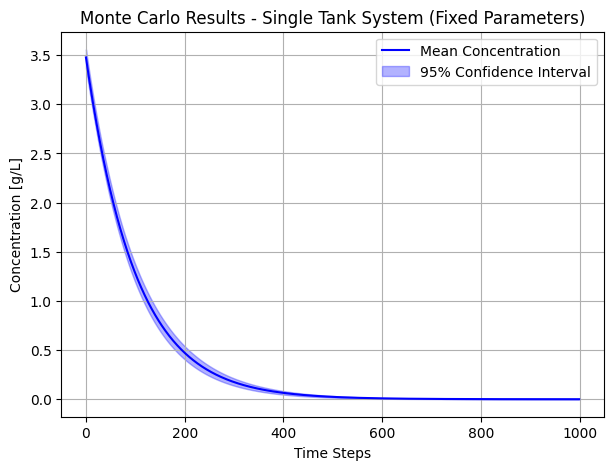

In [3]:
import matplotlib.pyplot as plt

#Plotting the result
time_steps = np.arange(n_steps)
plt.figure(figsize=(7, 5))
plt.plot(time_steps, c_mean_op1[0], color = 'blue',label = 'Mean Concentration')
plt.fill_between(time_steps, ci_lower_op1[0], ci_upper_op1[0], alpha = 0.3, color = 'blue', label = "95% Confidence Interval")
plt.legend()
plt.ylabel('Concentration [g/L]')
plt.xlabel('Time Steps')
plt.title('Monte Carlo Results - Single Tank System (Fixed Parameters)')
plt.grid()
plt.show()

The concentration decays exponentially towards zero, which is consistent with the absence of inflow to the tank. The uncertainty is relatively low at early times, increases towards the transition region (the "elbow" of the curve), and gradually decreases as the concentration approaches zero. A detailed comparison of both options is provided in Task $5$.

### Task 5 - Monte Carlo Simulation with Time-Varying Parameters (Option 2)

In Option $2$, the same Monte Carlo framework is used, but the flow rates are now allowed to fluctuate at each time step. The tank volume $V$ and initial concentration $C(0)$ are still sampled once per run and kept fixed throughout that run, whereas the inflow and outflow rates are resampled at every time step. The inflow concentration remains zero. More precisely, the parameters are treated as follows: 

Sampled once per run: 
* $V \sim \text{Uniform}(950, 1050)$ L
* $C(0) \sim \text{Uniform}(3.4, 3.6)$ g/L

Resampled at each time step
* $Q_{out} = Q_{in} \sim \text{Uniform}(95, 105)$ L/s
* $C_{in} = 0$ g/L (constant)


The configuration is implemented by calling the same `monte_carlo_simulation` function with the `fixed_parameters` variable set to `False`. 

In [4]:
#For task 5: parameters vary at each time step
fixed_parameters = False

#Perform Monte Carlo simulation with same settings as Task 4
(c_mean_op2,
 c_std_op2,
 ci_lower_op2,
 ci_upper_op2
) = monte_carlo_simulation(t_start, t_final, n_particles, n_steps, fixed_parameters)

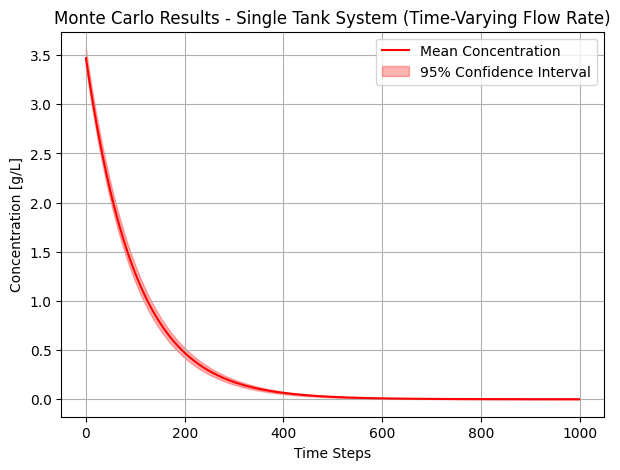

In [5]:
plt.figure(figsize=(7, 5))
plt.plot(time_steps, c_mean_op2[0], color = 'red', label = 'Mean Concentration')
plt.fill_between(time_steps, ci_lower_op2[0], ci_upper_op2[0], alpha = 0.3, color = 'red', label = "95% Confidence Interval")
plt.legend()
plt.ylabel('Concentration [g/L]')
plt.xlabel('Time Steps')
plt.title('Monte Carlo Results - Single Tank System (Time-Varying Flow Rate)')
plt.grid()
plt.show()

The concentration decays exponentially towards zero, with a visibly narrower confidence interval compared to Option $1$. This indicates that time-varying flow rates reduce the uncertainty in the concentration evolution. A systematic comparison between the two modelling approaches is presented in the following section.

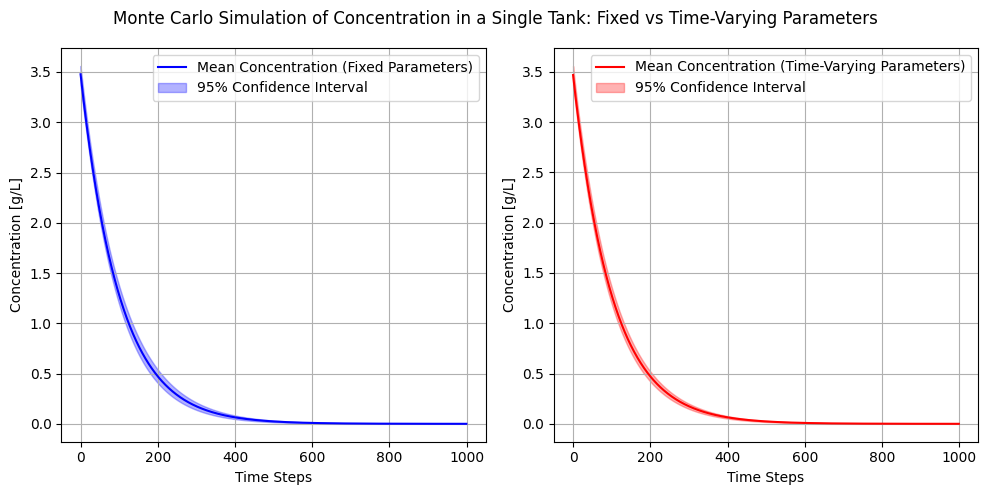

In [6]:
import matplotlib.pyplot as plt

time_steps = np.arange(n_steps)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(time_steps, c_mean_op1[0], color = 'blue',label = 'Mean Concentration (Fixed Parameters)')
plt.fill_between(time_steps, ci_lower_op1[0], ci_upper_op1[0], alpha = 0.3, color = 'blue', label = "95% Confidence Interval")
plt.legend()
plt.ylabel('Concentration [g/L]')
plt.xlabel('Time Steps')
plt.grid()


plt.subplot(1, 2, 2)
plt.plot(time_steps, c_mean_op2[0], color = 'red', label = 'Mean Concentration (Time-Varying Parameters)')
plt.fill_between(time_steps, ci_lower_op2[0], ci_upper_op2[0], alpha = 0.3, color = 'red', label = "95% Confidence Interval")
plt.legend()
plt.ylabel('Concentration [g/L]')
plt.xlabel('Time Steps')
plt.grid()


plt.suptitle('Monte Carlo Simulation of Concentration in a Single Tank: Fixed vs Time-Varying Parameters')
plt.tight_layout()
plt.show()


Both approaches show similar exponential decay behavior, but the fixed-parameter case exhibits a wider confidence interval than the time-varying case. This shows that when parameters are kept constant within each run, differences between runs persist over time, causing the simulation results to diverge more strongly and leading to greater variability.

Since the number of Monte Carlo runs is identical for both options, this difference cannot be attributed to sample size but rather sampling strategy. As mentioned in Gezerlis's book, Monte Carlo theory shows that such strategies can significantly affect estimator variance and uncertainty [\[$1$\]](#bib). 

To further quantify the difference in uncertainty, the width of the $95\%$ confidence interval is computed at each time step for both options. The mean interval width is then calculated as an overall measure of uncertainty, and the ratio between the two cases provides a direct comparison. The time evolution of the confidence interval width is also plotted to illusrate how to uncertainty develops throughout the simulation. 

In [7]:
width_op1 = ci_upper_op1[0] - ci_lower_op1[0]
width_op2 = ci_upper_op2[0] - ci_lower_op2[0]

mean_width_op1 = np.mean(width_op1)
mean_width_op2 = np.mean(width_op2)

print(f'Mean width option 1: {mean_width_op1:.4f} g/L')
print(f'Mean width option 2: {mean_width_op2:.4f} g/L')
print(f'Fixed parameters are {mean_width_op1/ mean_width_op2:.4f} times more uncertain')

Mean width option 1: 0.0549 g/L
Mean width option 2: 0.0459 g/L
Fixed parameters are 1.1975 times more uncertain


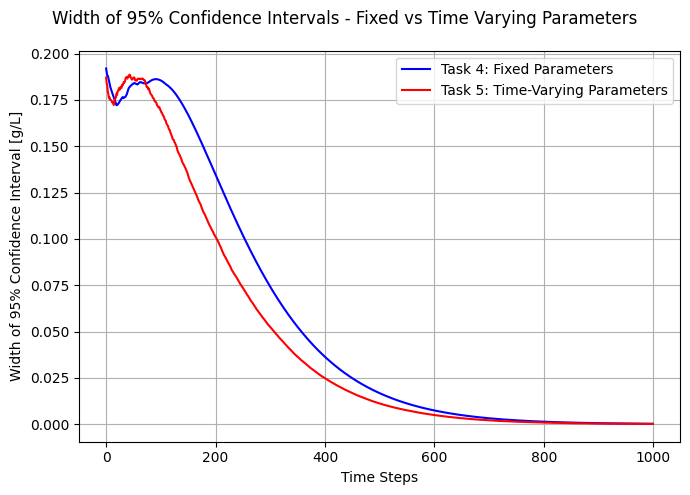

In [8]:
plt.figure(figsize=(7, 5))

plt.plot(time_steps, width_op1, color = 'blue',label = 'Task 4: Fixed Parameters')
plt.plot(time_steps, width_op2, color = 'red', label = 'Task 5: Time-Varying Parameters')
plt.legend()
plt.ylabel('Width of 95% Confidence Interval [g/L]')
plt.xlabel('Time Steps')
plt.grid()


plt.suptitle('Width of 95% Confidence Intervals - Fixed vs Time Varying Parameters')
plt.tight_layout()
plt.show()

The plot shows that the fixed-parameter case consistently has a wider confidence interval than the time-varying case. The mean widths of $0.0549$ g/L (Option 1) and $0.0459$ g/L (Option 2) indicate that the fixed-parameter model is about $1.20$ times more uncertain. This confirms that allowing the parameters to vary in time reduces the overall uncertainty in the concentration. 

## Part 2: Three Interconnected Tanks with Parameter Uncertainty

### Task 1 - Formulation of the Three-Tank System

The single-tank model from Part $1$ is now extended to a series of three mixed tanks with identical volume $V$. Tank $1$ receives an inflow with volumetric flow rate $Q_{in}$ and solute concentration $C_{in}$, while Tanks $2$ and $3$ receive their inflow from the preceding tank. Each tank discharges with flow rate $Q_{out}$. 

Let $C_1(t)$, $C_2(t)$, and $C_3(t)$ denote the solute concentration in Tanks $1$-$3$ respectively. The governing equations for the system are given by
\begin{align*}
    \frac{dC_1}{dt} =& \frac{Q_{in}}{V} C_{in} - \frac{Q_{out}}{V} C_1,\\
    \frac{dC_2}{dt} =& \frac{Q_{in}}{V} C_{1} - \frac{Q_{out}}{V} C_2,\\
    \frac{dC_3}{dt} =& \frac{Q_{in}}{V} C_{2} - \frac{Q_{out}}{V} C_3.
\end{align*}

The three tank system is implemented using the same `monte_carlo_simulation` function developed in Part $1$. As previously described, this function was designed to handle a variable number of tanks through the `n_tanks` parameter. Consequently, no structural changes to the simulation framework are required for the three-tank case. The model is extended simply by setting `n_tanks = 3`. This allows the concentration in all three interconnected tanks to be simulated simultaneously under the same Monte Carlo sampling strategy and parameter uncertainty formulation as before. 

### Task 2 - Monte Carlo Simulation for the Three-Tank System (Fixed Parameters per Run)

The three-tank model is analysed under parameter uncertainty using the Monte Carlo framwork established in Part $1$. In this configuration, all uncertain parameters are sampled once at the start of each run and kept constant throughout the simulation, corresponding to the fixed-parameter approach. The same `monte_carlo_simulation` function is employed, now with `n_tanks = 3` and `fixed_parameters = True`.

For each Monte Carlo run, the parameters are drawn from the following uniform distributions: 
* $V \sim \text{Uniform}(950,1050)$ L
* $Q_{in} = Q_{out} \sim \text{Uniform}(95,105)$ L/s
* $C_{in} 0$ g/L

Initial concentrations: 
* $C_1(0) \sim \text{Uniform}(3.4, 3.6)$ g/L
* $C_2(0) = C_3(0) \sim \text{Uniform}(0, 0.1)$ g/L

As in Part $1$, a total of $100$ independent runs are performed, each consisting of $1000$ time steps. As the total simulation time is not specified, a duration of $100$ seconds is chosen (consistent with Part $1$), giving $\Delta t = 0.1$ s. For each tank, the mean concentration, standard deviation, and $95\%$ confidence intervals are computed as functions of time.

In [9]:
(c_mean_3_tanks,
 c_std_3_tanks,
 ci_lower_3_tanks,
 ci_upper_3_tanks
) = monte_carlo_simulation(t_start, t_final, n_particles, n_steps, n_tanks = 3)

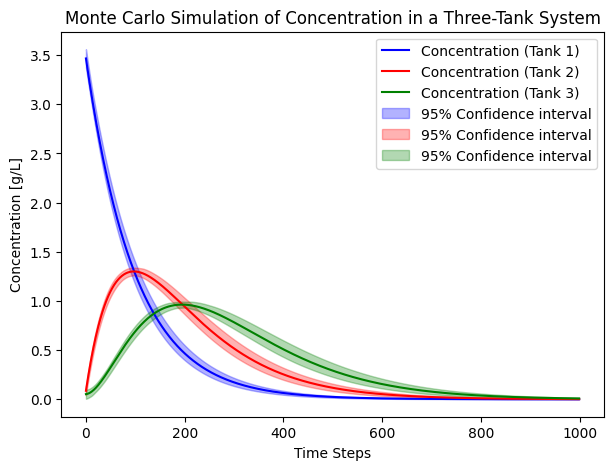

In [10]:
plt.figure(figsize=(7, 5))
plt.plot(time_steps, c_mean_3_tanks[0], color = 'blue', label = 'Concentration (Tank 1)')
plt.plot(time_steps, c_mean_3_tanks[1], color = 'red', label = 'Concentration (Tank 2)')
plt.plot(time_steps, c_mean_3_tanks[2], color = 'green', label = 'Concentration (Tank 3)')
plt.fill_between(time_steps, ci_lower_3_tanks[0], ci_upper_3_tanks[0], alpha = 0.3, color = 'blue', label = "95% Confidence interval")
plt.fill_between(time_steps, ci_lower_3_tanks[1], ci_upper_3_tanks[1], alpha = 0.3, color = 'red', label = "95% Confidence interval")
plt.fill_between(time_steps, ci_lower_3_tanks[2], ci_upper_3_tanks[2], alpha = 0.3, color = 'green', label = "95% Confidence interval")
plt.legend()
plt.ylabel('Concentration [g/L]')
plt.xlabel('Time Steps')
plt.title('Monte Carlo Simulation of Concentration in a Three-Tank System')
plt.show()

As seen in the plot above, tank $1$ decays rapidly, while Tanks $2$ and $3$ show delayed and lower peaks as the solute flows through the system. The confidence intervals indicate how uncertainty is transferred downstream.

## Part 3: Validation Againts ODE Solutions

To validate the stochastic simulations, the three-tank system is first solved deterministically using the average parameter values specified in the project description: 

$$V = 1000 \text{ L}, \quad Q_{out} = Q_{in} =  100 \text{ L/s}, \newline C_{in} = 0.25 \text{ g/L}, \quad C_1(0) = 3.5 \text{ g/L}, \quad C_2(0) = C_3(0) = 0 \text{ g/L}.$$

The deterministic reference solution is obtained using the general ODE solver developed in the previous project for this cource. This solver is capable of handling generic systems of ordinary differential equations and supports multiple numerical schemes. In the present work, the fourth-order Runge-Kutta method (RK4) with fixed step size is used. The Numba-accelerated version of the solver, although available in the original implementation, is not included in the delivery of this project. 

The function `diff_eqns` defines the governing equations for the three-tank system, returning the time derivatives of the concentration in each tank. The system is integrated over the interval $t \in [0,100]$ s with time step $\Delta t = 0.1$ s and the specified initial conditions. 

In [11]:
from ode_solver import ODESolver

def diff_eqns(c, t):
    ''' 3-tank system '''
    v = 1000
    q_in = q_out = 100
    c_in = 0.25

    c_1, c_2, c_3 = c
    dc = np.zeros(len(c))

    dc[0] = q_in/v * c_in - q_out/v * c_1 #Tank 1
    dc[1] = q_in/v * c_1 - q_out/v * c_2 #Tank 2
    dc[2] = q_in/v * c_2 - q_out/v * c_3 #Tank 3

    return dc

obj = ODESolver(diff_eqns, 0, 100, 0.1, [3.5, 0, 0], 'rk4', adaptive = False)
t_num, c_num = obj.solve()

The section below adjusts the time vector and trims the solution arrays so they align with the Monte Carlo time steps, enabling direct comparison between the deterministic and stochastic results.

In [12]:
#Convert physical time to match MC timesteps
t_num = t_num * 10
t_num = t_num[:len(time_steps)]
c_num = c_num[:len(time_steps)]

The Monte Carlo simulation is then rerun to obtain stochastic results for validation against the ODE solution. To ensure consistency, the inflow concentration is set to `c_in = 0.25 g/L`, matching the average parameter value. 

In [13]:
(c_mean_3_tanks_val,
 c_std_3_tanks_val,
 ci_lower_3_tanks_val,
 ci_upper_3_tanks_val
) = monte_carlo_simulation(t_start, t_final, n_particles, n_steps, n_tanks = 3, c_in = 0.25)

### Task 1 - Comparison between Monte Carlo and ODE solutions

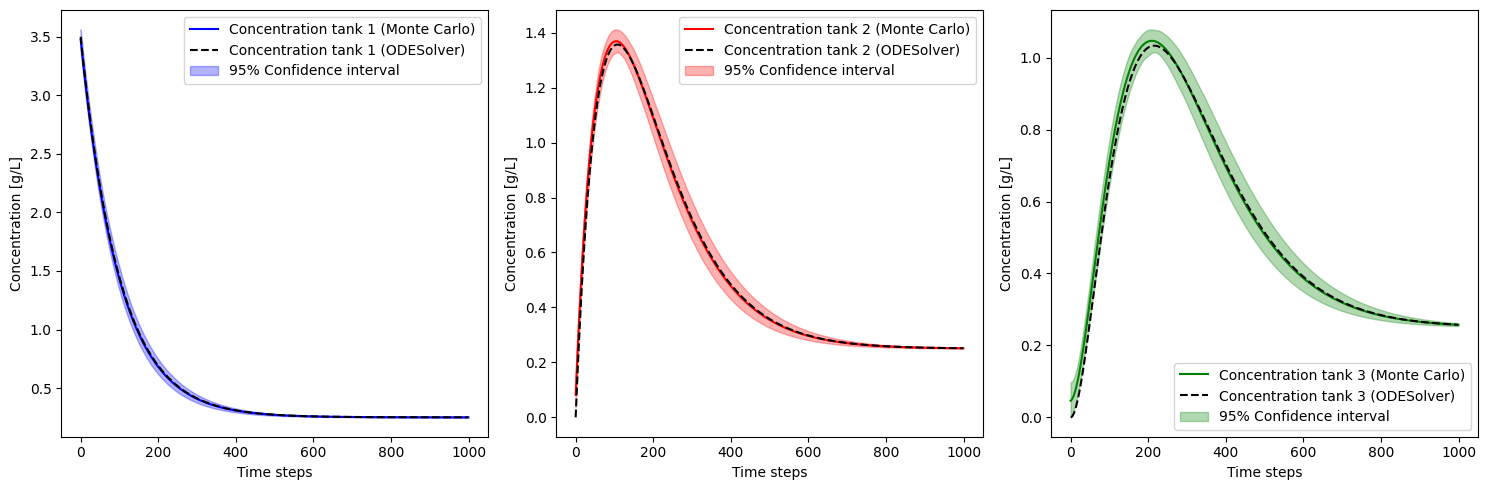

In [14]:
plt.figure(figsize=(15, 5))
colors = ['blue', 'red', 'green']

for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.plot(time_steps, c_mean_3_tanks_val[i], color = colors[i], label = f'Concentration tank {i + 1} (Monte Carlo)')
    plt.plot(t_num, c_num[:, i],'--', color = 'black', label = f'Concentration tank {i + 1} (ODESolver)')
    plt.fill_between(time_steps, ci_lower_3_tanks_val[i], ci_upper_3_tanks_val[i], alpha = 0.3, color = colors[i], label = "95% Confidence interval")
    plt.legend()
    plt.ylabel('Concentration [g/L]')
    plt.xlabel('Time steps')

plt.tight_layout()
plt.show()

From the plot above, the deterministic ODE solution closely follows the mean concentration obtained from the Monte Carlo simulation for all three tanks. In each case, the ODE curve lies within the $95\%$ confidence interval of the stochastic results, indicating good agreement between the two approaches. Minor deviations are visible around the peak regions for Tanks $2$ and $3$, but these remain well within the uncertainty bounds. This confirms that the stochastic model reproduces the expected deterministic behavior when average parameters are applied. 

### Task 2 - Evaluation of Accuracy, Consistency, and Computational Efficiency

In this task, the Monte Carlo simulation is evaluated by comparison with the deterministic ODE solution using three numerical measures: Mean Absolute Error (MAE) for accuracy, confidence interval (CI) width for consistency, and execution time for computational efficiency.

**Accuracy**

Accuracy is measured using the Mean Absolute Error (MAE), which represents the average absolute difference between the Monte Carlo mean and the ODE solution. MAE is a commonly used and easily interpretable error measure, as it directly shows the average deviation in physical units (g/L) [\[$2$\]](#bib). 

In [15]:
mae = np.mean(np.abs(c_mean_3_tanks_val - c_num.T), axis = 1)
print('Mean absolute error')
print(f'Tank 1 MAE = {mae[0]:.4f}')
print(f'Tank 2 MAE = {mae[1]:.4f}')
print(f'Tank 3 MAE = {mae[2]:.4f}')

Mean absolute error
Tank 1 MAE = 0.0047
Tank 2 MAE = 0.0074
Tank 3 MAE = 0.0117


The obtained MAE values of $0.0047$, $0.0074$ and $0.0117$ g/L for Tanks $1$-$3$ indicate very close agreement, confirming that the Monte Carlo model accurately reproduces the deterministic behavior. 

**Consistency**

Consistency is interpreted as how much the simulation results vary when the model is run multiple times with the same settings. The width of the $95\%$ confidence interval is therefore used as a measure of consistency, as it directly reflects the spread of the Monte Carlo outcomes around the mean. 

In [16]:
width_val = ci_upper_3_tanks_val - ci_lower_3_tanks_val
mean_width_val = np.mean(width_val, axis = 1)
print('Mean width of confidence interval')
print(f'Tank 1 width = {mean_width_val[0]:.4f}')
print(f'Tank 2 width = {mean_width_val[1]:.4f}')
print(f'Tank 3 width = {mean_width_val[2]:.4f}')

Mean width of confidence interval
Tank 1 width = 0.0547
Tank 2 width = 0.0655
Tank 3 width = 0.0778


The mean CI widths of $0.0547$, $0.0655$ and $0.0778$ g/L indicates low variability and therefore strong consistency. The gradual increase for downstream tanks reflect accumulated uncertainty as the solute passes through the system. 

**Computational efficiency**

Computational efficiency is evaluated using the execution time measured with the `timeit` module [\[$3$\]](#bib). The deterministic ODE solver is expected to be faster than the Monte Carlo simulation, as the Monte Carlo methods rely on a large number of repeated runs and are therefore computationally inefficient. The error in Monte Carlo simulations scales as $1/\sqrt{N}$, meaning that reducing the error by a factor of $10$ requires approximately 100 time more runs [\[$4$\]](#bib). 

In [17]:
import timeit

#Number of tests
number = 5

#Creating instances of ODESolver
ode_solver = ODESolver(diff_eqns, 0, 100, 0.1, [3.5, 0, 0], 'rk4', adaptive = False)

#Time it and calculate average on each run
time_ode_solver = timeit.timeit(lambda: ode_solver.solve(), number = number) / number
time_mc_sim = timeit.timeit(lambda: monte_carlo_simulation(t_start, t_final, n_particles, n_steps, n_tanks = 3, c_in = 0.25), number = number) / number
#Print result
print(f"Solving numerically: {time_ode_solver:.4f} s")
print(f"Solving stochastically: {time_mc_sim:.4f} s")
print(f"Stochastically is {time_mc_sim/time_ode_solver:.2f} times slower")

Solving numerically: 0.0393 s
Solving stochastically: 0.3577 s
Stochastically is 9.10 times slower


As expected, the Monte Carlo simulation is approximately $10$-$15$ times slower than the deterministic solver, reflecting the increased computational cost associated with repeated stochastic sampling.

Overall, the Monte Carlo model demonstrates strong accuracy and consistency, but at the cost of increased computational effort.

### Task 3 - Advantages and Limitations of Monte Carlo vs Deterministic ODE Methods

Monte Carlo simulations capture variability and provide confidence intervals, making them well-suited for modelling uncertainty. However, they are computationally expensive due to the large number of runs required for convergence [\[$4$\]](#bib). 

In contrast, the deterministic solution using the fourth-order Runge-Kutta method (RK4) is fast, stable, and highly accurate, with numerical error decreasing proportionally to the fourth power of the time step $\left(\mathcal{O}\left(\Delta t^4 \right)\right)$ [\[$5$\]](#bib). While RK4 provides smooth and precise solutions, it produces only a single trajectory and does not account for uncertainty. 

In summary, Monte Carlo offers uncertainty quantification, while RK4 provides efficient and precise deterministic predictions. 

# Exercise 2: Spreading of Contaminants in Underground Aquifers Using Random Walk

Exercise $2$ uses a two-dimensional random walk to model how contaminants spread from a source in an aquifer. We first run the model with equal movement in all directions and then add a directional bias. The results show how the choice of movement patterns affect the spread and the time it takes to reach a given distance. 

## Part 1: 2D Random Walk Model

### Task 1 - Basic Random Walk Model 

The random walk is implemented in the `random_walk_2d` function, which simulates the motion of a single particle in two dimensions. The function continuously updates the particle's position by selecting one of the allowed movements. Each particle can take at most `n_steps`, but the walk terminates earlier if the particle attempts to move outside the predefined `bounds`.

In [18]:
import random
random.seed(18)

def random_walk_2d(n_steps, directions, start_pos = (1000, 1000), bounds = (0, 2000), probabilities = None):
    '''
    Simulated a 2D random walk for a single particle.

    Input
    ------
    n_steps: int
        Maximum number of steps to simulate.
    directions: list(tuple)
        List of possible movement directions (dx, dy).
    start_pos: tuple
        (x, y) start coordinates.
    bounds: tuple
        (min, max) allowed domain in both x and y.
    probabilities: ndarray or None
        Movement probabilities matching directions list

    Output
    ------
    x_path: list
        The x-coordinates of the particle at each step of the walk.
    y_path: list
        The y-coordinates of the particle at each step of the walk.
    '''
    #Start position
    x, y = start_pos
    x_path = [x]
    y_path = [y]

    for _ in range(n_steps):
        #Choose a dicection at randon
        if probabilities is None:
            dx, dy = random.choices(directions)[0]
        else:
            dx, dy = random.choices(directions, weights = probabilities)[0]

        #Walk
        x += dx
        y += dy

        #Boundary check
        if not (bounds[0] <= x <= bounds[1] and bounds[0] <= y <= bounds[1]):
            break

        x_path.append(x)
        y_path.append(y)

    return x_path, y_path

**Initialization of the Particle Grid**

To place $1000$ particles on a square grid centered at $(1000, 1000)$, we first determine the smallest square grid that can hold at least $1000$ points. Since

$$\text{side} = \left\lceil\sqrt{1000}\right\rceil = 32 \text{,}$$

a $32 \times 32 = 1024$ grid is sufficient.

The midpoint index of this grid is

$$\text{midpoint} = \left\lfloor \frac{\text{side}}{2} \right\rfloor = 16.$$

By subtracting this midpoint from each grid index gives the negative offsets on one side of the center, positive offsets on the other, and zero at the center. Adding these offsets to the value $1000$ centers the grid at $(1000, 1000)$. 

A spacing of $3$ units is used to spread the grid points evenly around the center without making the initial cluster too dense. 

In [19]:
n_particles = 1000

side = int(np.ceil(np.sqrt(n_particles)))
midpoint = side // 2

spacing = 3

grid_pos = [(1000 + (i - midpoint) * spacing,
             1000 + (j - midpoint)* spacing)
             for i in range(side)
             for j in range(side)]
start_pos = grid_pos[:n_particles]

**Definition of Allowed Movement Directions**

After defining the initial grid, we specify the set of directions a particle is allowed to move. At each time step a particle may take one step in the positive or negative $x$- or $y$- direction, or it may remain in its current position. Diagonal movement is not permitted. In this basic model no movement probabilities are assigned, meaning that each direction is selected with equal likelihood by the default behavior of the Python `random.choices` function [\[$6$\]](#bib).

In [20]:

#Directions to choose from (dx, dy)
north = (0, 1)
south = (0, -1)
east = (1, 0)
west = (-1, 0)
stay = (0, 0)

directions = [north, south, east, west, stay]

**Simulating the Random Walk**

With the grid and movement directions defined, each particle can now perform a random walk of up to $1000$ steps. For every starting position in the grid, the function `random_walk_2d` is called to generate its trajectory. The final position of each particle is stored, and the complete path of a selceted particle, here particle number $200$, is extraced for visualization.

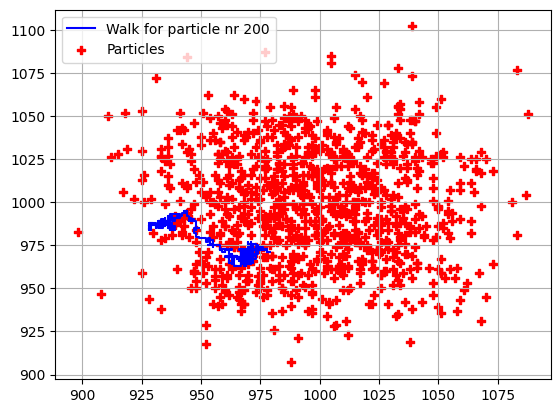

In [21]:
n_steps = 1000

points = []
paths = []

for pos in start_pos:
    x_path, y_path = random_walk_2d(n_steps, directions, pos)
    paths.append((x_path, y_path))
    points.append((x_path[-1], y_path[-1]))

x_coords, y_coords = zip(*points)

#Path of particle 200
x_200, y_200 = paths[200]

#Plotting
plt.plot(x_200, y_200, '-', color = 'blue', label = 'Walk for particle nr 200')
plt.scatter(x_coords, y_coords, marker = 'P', color = 'red', label = 'Particles')
plt.legend()
plt.grid()
plt.show()

The resulting plot shows both the trajectory of this single particle and the final position of all particles after the random walk, illustrating how the contamination spreads over time.

### Task 2 - Probability-Weighted Movement

For the weighted model, the `random_walk_2d` function was updated to support probability-weighted movement through its `probabilities` argument. In addition to implementing weighted movement, the set of directions is expanded to include nine combinations of $(dx, dy)$, which also means that diagonal movement must be allowed in this task. Each movement direction is assigned a probability such that the total sums to one. Two probability distributions were tested: one that gives a slightly higher weight to stay in place to model slow diffusion, and another that strongly favors movement north to introduce a clear directional bias.

In [22]:
#Directions to choose from (dx, dy)
north = (0, 1)
north_west = (-1, 1)
north_east = (1, 1)
south = (0, -1)
south_west = (-1, -1)
south_east = (1, -1)
east = (1, 0)
west = (-1, 0)
stay = (0, 0)

directions_w = [north,
               north_west,
               north_east,
               south,
               south_west,
               south_east,
               east,
               west,
               stay]

#Slow diffusion
probabilities_slow = np.array([0.1,  #north
                               0.1,  #north west
                               0.1,  #north east
                               0.1,  #south
                               0.1,  #south west
                               0.1,  #south east
                               0.1,  #east
                               0.1,  #west
                               0.2]) #stay

#Directional bias
probabilities_north = np.array([0.6,   #north
                                0.05,  #north west
                                0.05,  #north east
                                0.05,  #south
                                0.05,  #south west
                                0.05,  #south east
                                0.05,  #east
                                0.05,  #west
                                0.05]) #stay

#Make sure sum of probabilitiesis is 1
assert np.isclose(probabilities_slow.sum(),1), 'Probabilities must sum to 1'
assert np.isclose(probabilities_north.sum(),1), 'Probabilities must sum to 1'

Using the two probability distributions, the simulation is run again to generate a set of particle trajectories for each case. As before, the final positions are collected, and the path of particle $200$ is plotted to illustrate how the two probability choices influence the resulting spread.

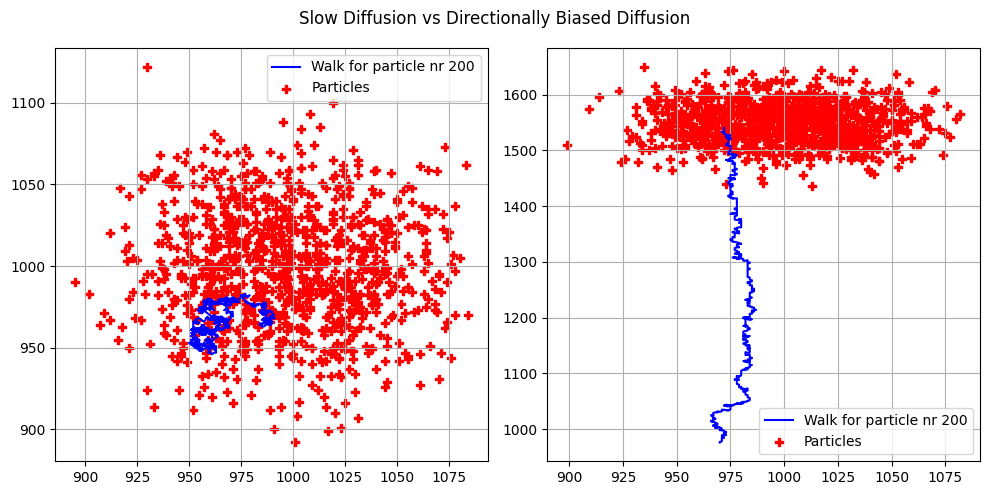

In [23]:
probabilities = [probabilities_slow, probabilities_north]
n_steps_w = 1000
i = 1

plt.figure(figsize=(10, 5))
for prob in probabilities:
    points_w = []
    paths_w = []

    plt.subplot(1, 2, i)
    for pos in start_pos:
        x_path_w, y_path_w = random_walk_2d(n_steps_w, directions_w, pos, probabilities = prob)
        paths_w.append((x_path_w, y_path_w))
        points_w.append((x_path_w[-1], y_path_w[-1]))

    x_coords_w, y_coords_w = zip(*points_w)

    #Path of particle 200
    x_200_w, y_200_w = paths_w[200]

    #Plotting
    plt.plot(x_200_w, y_200_w, '-', color = 'blue', label = 'Walk for particle nr 200')
    plt.scatter(x_coords_w, y_coords_w, marker = 'P', color = 'red', label = 'Particles')
    plt.legend()
    plt.grid()
    i += 1

plt.suptitle('Slow Diffusion vs Directionally Biased Diffusion')
plt.tight_layout()
plt.show()

The slow-diffusion case produces a mostly symmetric spread around the center, while the north-biased case shows a strong upward drift, resulting in a highly asymmetric distribution and a much more directed trajectory for particle $200$. 

## Part 2: 2D Random Walk Model of Contaminant Transport in Aquifers

### Task 1 - Defining the Contaminant Source

The source of contamination is located at the central grid point $(1000, 1000)$, which represents the physical release location in the aquifer. 

In [24]:
source_x = 1000
source_y = 1000
source = (source_x, source_y)

### Task 2 - Worst-Case Travel Time Estimation

In the worst-case scenario, assuming straight-line motion at the maximum migration rate of $10$ m/year, the contaminant reaches the target distance in
$$t_{\text{min}} = \frac{\text{distance}}{\text{rate}} = \frac{10 000 \text{ m}}{10 \text{ m/year}} = 1000 \text{ years.}$$
Thus, a minimum of $1000$ years is required for the contaminant to travel $10$ km under this assumption. 

### Task 3 - Simulating Contaminant Spread

For this task, the contaminant is restricted to move only in four directions: north, south, east and west. These directions are stored in the list `directions_4`, which is passed to the `random_walk_2d` function. Since no probability vector is supplied, the function uses its default argument `probabilities = None`, meaning each movement direction is chosen with equal probability. 

In [25]:
directions_4 = [north, south, east, west]

Using this setup, a total of $2000$ particles are released from the source at $(1000, 1000)$ and each particle performs a $2000$-step random walk. The `random_walk_function` is used to generate these trajectories, and only the final positions are recorded. A 2D histogram is then used to visualize the resulting distribution.

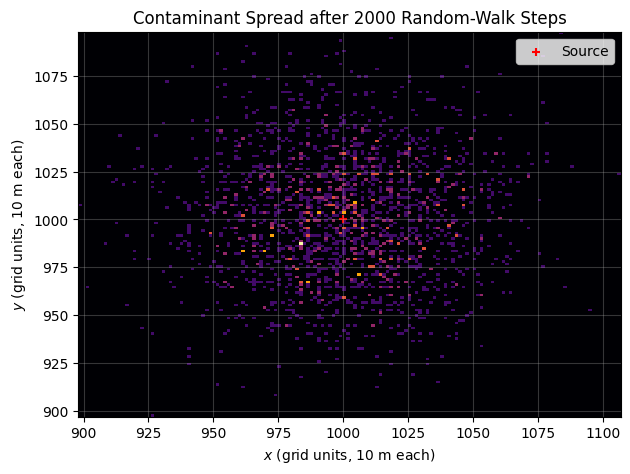

In [26]:
n_particles_4 = 2000
n_steps_4 = 2000

final_pos_4 = []

for i in range(n_particles_4):
    x_path_4, y_path_4 = random_walk_2d(n_steps_4, directions_4, source)
    final_pos_4.append((x_path_4[-1], y_path_4[-1]))

final_pos_x_4, final_pos_y_4 = zip(*final_pos_4)

#Plotting
plt.figure(figsize=(7, 5))
plt.hist2d(final_pos_x_4, final_pos_y_4, bins= 150, cmap = 'inferno')
plt.scatter(1000, 1000, color='red', marker='+', label='Source')
plt.legend()
plt.grid(alpha = 0.3)
plt.title(f'Contaminant Spread after {n_steps_4} Random-Walk Steps')
plt.xlabel(r'$x$ (grid units, $10$ m each)')
plt.ylabel(r'$y$ (grid units, $10$ m each)')
plt.show()

The resulting concentration map shows how the contaminant spreads outward from the source after $2000$ random-walk steps. Because each movement direction is equally likely, the distribution is roughly symmetric, with the highest particle density near the source and gradually decreasing concentrations farther away. 

### Task 4 - Time to Reach 10 km (Unbiased Random Walk)

To estimate how long it takes for the contaminant to reach $10$ km from the source under an unbiased random walk, we run multiple simulations and record the first time the particle crosses this distance. Each step corresponds to $10$ m of travel and $1$ year of time. The function `time_to_reach_distance` preforms this simulation by advancing the particle until its distance from the start exceeds the target value.

In [27]:
random.seed(67)
def time_to_reach_distance(distance_to_reach, start_pos, grid_unit, directions, probabilities = None, mode = 'radial', max_time = 1e10):
    '''
    Simulate a 2D random walk and compute the time required of a particle to
    reach a specified distance from its starting location.

    Input
    ------
    distance_to_reach: float
        Target travel distance in meters.
    start_pos: tuple(int, int)
        Initial (x,y) position of the particle in grid units.
    grid_unit: float
        Physical size of one grid step in meters.
    directions: list[tuple]
        List of possible movement directions (dx, dy).
    probabilities: ndarray or None
        Movement probabilities matching directions list.
        If None, all directions are chosen with equal probability.
    mode: str
        Determines stopping condition:
            - 'radial': stop when the radial distance from start point
                        reaches the target distance (Task 4).
            - 'south':  stop when the particle has moved the target
                        distance directly south of the start point
                        (Task 5).
    max_time: int
        Maximum allowed number of steps (years) before the simulation
        aborts,

    Output
    ------
    years: int
        Number of steps (years) required to reach target distance.
        If years exceed max_years, then max_years is returned.
    '''
    years = 0

    #Squared to improve computational speed
    distance_grid = distance_to_reach / grid_unit
    target_radial = (distance_grid)**2
    target_south = start_pos[1] - distance_grid

    #Start position
    x, y = start_pos

    while years < max_time:
        #Choose a dicection at randon
        if probabilities is None:
            dx, dy = random.choice(directions)
        else:
            dx, dy = random.choices(directions, weights = probabilities)[0]

        #Walk
        x += dx
        y += dy

        #Steps (years)
        years += 1

        #See if distance is reached
        if mode == 'radial':
            distance = (x - start_pos[0])**2 + (y - start_pos[1])**2
            if distance >= target_radial:
                return years

        elif mode == 'south':
            if y <= target_south:
                return years
    #If no return happened inside the loop
    return max_time

Below, the starting position is set to $(0,0)$, and we run $50$ unbiased simulations using equal-probability movement in four directions to obtain the arrival times. 

In [28]:
arrival_times_unbiased = []
distance_to_reach = 10_000
start_pos_unbiased = (0, 0)
grid_unit = 10
directions_unbiased = [north, south, east, west]

n_runs = 50

for i in range(n_runs):
    arrival_times_unbiased.append(time_to_reach_distance(distance_to_reach,
                                                         start_pos_unbiased,
                                                         grid_unit,
                                                         directions_unbiased))

Before interpreting the result, we fit both a lognormal and a normal distribution to the simulated arrival times. This provides a basis for comparing the distributions with the histogram evaluating whether the unbiased arrival times are approximately normal or exhibit a more skewed behavior. 

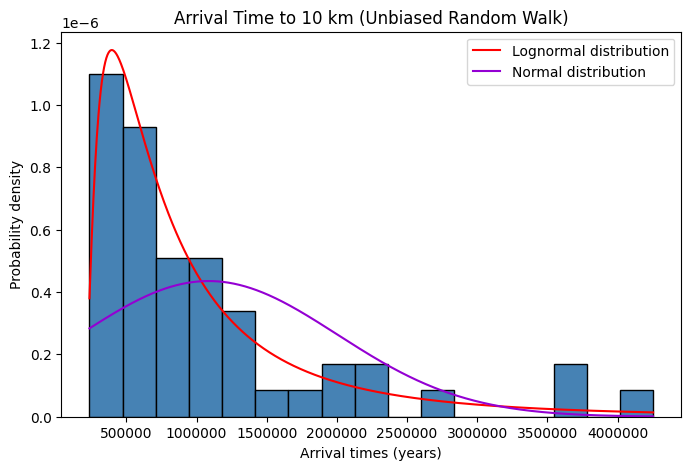

In [29]:
import scipy.stats as stats

#Distributions
arrival_times_unbiased = np.array(arrival_times_unbiased)
shape, loc, scale = stats.lognorm.fit(arrival_times_unbiased)
mu, sigma = arrival_times_unbiased.mean(), arrival_times_unbiased.std()
x = np.linspace(min(arrival_times_unbiased), max(arrival_times_unbiased), 1000)


#Plotting
plt.figure(figsize=(8, 5))
plt.hist(arrival_times_unbiased, bins=17,density=True, edgecolor='black', color = 'steelblue')
plt.title('Arrival Time to 10 km (Unbiased Random Walk)')
plt.plot(x, stats.lognorm.pdf(x, shape, loc, scale), color = 'red', label = 'Lognormal distribution')
plt.plot(x, stats.norm.pdf(x, mu, sigma), color = 'darkviolet', label = 'Normal distribution')
plt.xlabel('Arrival times (years)')
plt.ylabel('Probability density')
plt.legend()
plt.ticklabel_format(style='plain', axis='x')
plt.show()

The histogram of arrival times shows a highly right-skewed distribution, indicating large variability in how long an unbiased random walk requires to reach $10$ km. The fitted lognormal curve aligns more closely with the simulated data than the normal distribution. 

### Task 5 - Introducing Net Transport (Biased Random Walk)

To introduce directional transport, we adjust the movement probabilities so that the particle is more likely to move south than in any other direction. Specifically, the probability of moving south is set to be twice the probability of moving, north, east or west which all remain equal.

In [30]:
start_pos_biased = start_pos_unbiased
directions_biased = directions_unbiased

probabilities_biased = np.array([0.2,  #North
                                 0.4,  #South
                                 0.2,  #East
                                 0.2]) #West

#Make sure sum of probabilities is 1
assert np.isclose(probabilities_biased.sum(),1), 'Probabilities must sum to 1'

With the biased movement rules defined, we now compute the arrival times for reaching $10$ km south. Each simulation tracks how long it takes for the particle to cross the southward target position using the `time_to_reach_distance` function with `mode = 'south'`. 

In [31]:
arrival_times_biased = []

n_runs = 1000

for i in range(n_runs):
    arrival_times_biased.append(time_to_reach_distance(distance_to_reach,
                                                       start_pos_biased,
                                                       grid_unit,
                                                       directions_biased,
                                                       probabilities_biased,
                                                       mode = 'south'))

To compare the unbiased case, we now examine the distribution of arrival times under the south-biased movement. The histogram is plotted together with a fitted normal curve to assess how well a Gaussian distribution captures the biased arrival times. 

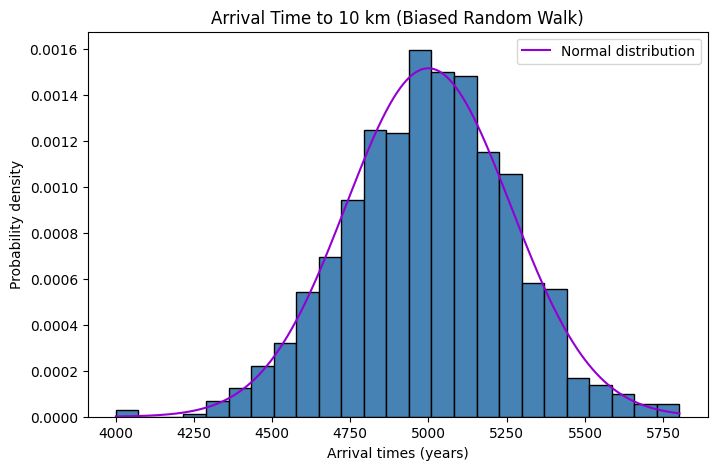

In [32]:
arrival_times_biased = np.array(arrival_times_biased)
mu_biased, sigma_biased = arrival_times_biased.mean(), arrival_times_biased.std()
x_biased = np.linspace(min(arrival_times_biased), max(arrival_times_biased), 1000)

plt.figure(figsize=(8, 5))
plt.hist(arrival_times_biased, bins=25, density=True, edgecolor='black', color = 'steelblue')
plt.title('Arrival Time to 10 km (Biased Random Walk)')
plt.plot(x_biased, stats.norm.pdf(x_biased, mu_biased, sigma_biased), color = 'darkviolet', label = 'Normal distribution')
plt.xlabel('Arrival times (years)')
plt.ylabel('Probability density')
plt.legend()
plt.ticklabel_format(style='plain', axis='x')
plt.show()

The arrival time distribution under the southward bias is much tighter and more symmetric than in the unbiased case. The fitted normal curve aligns closely with the histogram, indicating that the biased arrival times are approximately normally distributed. 

**Most Likely Arrival-Time Ratio: Unbiased vs Biased Transport**

To compare how quickly the contaminant reaches $10$ km south under unbiased and biased transport, we run $100$ simulations for each case and store the arrival time. A maximum simulation time of $5 \space 000 \space 000$ years is imposed to prevent endlessly wandering particles from causing infinite loops.

In [33]:
#Number of simulations
n_runs_10k_south = 100

#Max allowed travel time (years)
max_time = 5_000_000

#Lists to store arrival times
arrival_times_unbiased_south = []
arrival_times_biased_south = []

In [34]:
#Unbiased case simulation
for _ in range(n_runs_10k_south):
    arrival_times_unbiased_south.append(
        time_to_reach_distance(distance_to_reach,
                               start_pos_unbiased,
                               grid_unit,
                               directions_unbiased,
                               None,
                               'south',
                               max_time))

#Biased case simulation
for _ in range(n_runs_10k_south):
    arrival_times_biased_south.append(
        time_to_reach_distance(distance_to_reach,
                               start_pos_biased,
                               grid_unit,
                               directions_biased,
                               probabilities_biased,
                               'south',
                               max_time))

After the simulations, we convert the arrival time lists to NumPy arrays and remove all runs that hit the maximum allowed time. The remaining values represent only the particles the successfully reached $10$ km south. 

In [35]:
#Convert to NumPy array
arrival_times_unbiased_south = np.array(arrival_times_unbiased_south)
arrival_times_biased_south = np.array(arrival_times_biased_south)

#Identify simulations that reached the target before max_time
mask_success_unbiased = arrival_times_unbiased_south < max_time
mask_success_biased = arrival_times_biased_south < max_time

#Keep only successful arrival times
arrival_success_unbiased = arrival_times_unbiased_south[mask_success_unbiased]
arrival_success_biased = arrival_times_unbiased_south[mask_success_biased]

With successful arrival times isolated, we estimate the most common arrival time by computing a histogram and identifying the bin with the highest count. The left edge of this bin is taken as the peak arrival time, representing the time interval in which arrivals occur most frequently [\[$7$\]](#bib) [\[$8$\]](#bib).

In [36]:
#Unbiased mode
counts_unbiased, bins_unbiased = np.histogram(arrival_success_unbiased, bins=30)
peak_time_unbiased = bins_unbiased[np.argmax(counts_unbiased)]

#Biased mode
counts_biased, bins_biased = np.histogram(arrival_times_biased_south, bins=30)
peak_time_biased = bins_biased[np.argmax(counts_biased)]

print(f'Successful runs (unbiased): {mask_success_unbiased.sum()}')
print(f'Successful runs (biased): {mask_success_biased.sum()}')

Successful runs (unbiased): 52
Successful runs (biased): 100


Only $52$ of $100$ unbiased walks reached $10$ km south within the allowed time, while all $100$ biased walks succeeded.

The ratio compares how much faster the biased walk reaches $10$ km south compared to the unbiased case. A ratio above $1$ means that the south-biased walk reached $10$ km faster than the unbiased walk. 

In [37]:
ratio = peak_time_unbiased / peak_time_biased
print(f'Ratio of most likely arrival times (unbiased / biased): {ratio:.2f}')

Ratio of most likely arrival times (unbiased / biased): 212.14


These results show that south-biased transport reaches $10$km south dramatically faster than the unbiased random walk. Using the most frequently observed arrival times, the unbiased case is over $200$ times slower than the biased case.

# Self-reflection
### Simen
I am happy with the outcome of this project, and it was interesting to see how relatively simple simulations can model complex systems so accurately. I underestimated the amount of work required in this project, and ended up quite busy toward the end, but the process was still rewarding. This is the last report in this course, and I must say I have really enjoyed it and learned a lot throughout. 

### Nataliia
I learned how to implement the Monte Carlo method and compared it with a deterministic solution. This project was not as difficult as the second and third ones, perhaps because this was the last one, and going step by step helped me understand the material better. Based on this project, we can draw some conclusions. The deterministic solution is perfect when we know the exact parameters and only need average behavior, but in real life parameters are almost never exactly known. The Monte Carlo method is much better because it tells us not only what is likely to happen, but also how uncertain the prediction is. In addition, I want to say that the labs were not as helpful as the previous ones, but the professor was available and ready to help by email. I wish I could have gotten more help in the labs, but overall, I did not have difficulties with this project. I think I like the Monte Carlo method the most. 

# Conclusion

This project demonstrated the effectiveness of stochastic methods for modelling uncertainty and transport processes. For the mixing tank models, Monte Carlo simulations closely matched the deterministic ODE solutions when using average parameters. The width of the confidence intervals provided a measure of uncertainty, while the execution time measurements showed the expected runtime measurement, highlighting the trade-off between Monte Carlo sampling and faster deterministic solvers. 

In the aquifer contamination model, the 2D random walk showed very different results depending on whether the movement was unbiased or had a preferred direction. With no bias, travel times were very widespread and often extremely long. When a southward bias was added, the contaminants reached the target much faster and the travel times became shorter. This shows how a preferred movement direction can strongly affect how quickly contaminations spreads. 

Overall, the project shows how stochastic methods can give important insight into uncertainty and help improve the understanding of complex systems. 

# Bibliography
<a id="bib"></a>

\[$1$\] A. Gezerlis, *Numerical Methods in Physics with Python*, 2nd ed. Cambridge, UK: Cambridge University Press, 2023.

\[$2$\] “Mean absolute error,” Wikipedia, The Free Encyclopedia. [Online]. Available: https://en.wikipedia.org/wiki/Mean_absolute_error. [Accessed: 27-Nov-2025].

\[$3$\] “timeit — Measure execution time of small code snippets,” Python 3.14.0 documentation, Python Software Foundation. [Online]. Available: https://docs.python.org/3/library/timeit.html. [Accessed: 28-Nov-2025].


\[$4$\] M. Newman, *Computational Physics*. San Francisco, CA, USA: CreateSpace Independent Publishing Platform, 2013.

\[$5$] A. Hiorth, *Computational Engineering and Modeling*. [Online]. Available: https://github.com/ahiorth/CompEngineering. [Accessed: 28-Nov-2025].

\[$6$] “random — Generate pseudo-random numbers,” Python 3 documentation, Python Software Foundation. [Online]. Available: https://docs.python.org/3/library/random.html. [Accessed: 28-Nov-2025].


\[$7$] “numpy.histogram — NumPy v2.3 Manual,” NumPy Documentation. [Online]. Available: https://numpy.org/doc/2.3/reference/generated/numpy.histogram.html. [Accessed: 30-Nov-2025].


\[$8$] “numpy.argmax — NumPy v2.2 Manual,” NumPy Documentation. [Online]. Available: https://numpy.org/doc/2.2/reference/generated/numpy.argmax.html. [Accessed: 30-Nov-2025].
